https://icn613ex66e1.feishu.cn/wiki/R2BOwmZeiiCzLck5chScbsmcnPc

In [1]:
from collections import OrderedDict
import pandas as pd

examDict = {
    '学习时间':[0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 1.75, 2.00, 2.25, 2.50, 2.75, 3.00, 3.25, 3.50, 4.00, 4.25, 4.50, 4.75, 5.00, 5.50],    
    '分数':[10,22, 13, 43, 20, 22, 33, 50, 62,48, 55, 75, 62, 73, 81, 76, 64, 82, 90, 93]
}
examOrderDict = OrderedDict(examDict) 
exam = pd.DataFrame(examOrderDict)
# 查看数据格式
#print(exam.head())
print(exam)

    学习时间  分数
0   0.50  10
1   0.75  22
2   1.00  13
3   1.25  43
4   1.50  20
5   1.75  22
6   1.75  33
7   2.00  50
8   2.25  62
9   2.50  48
10  2.75  55
11  3.00  75
12  3.25  62
13  3.50  73
14  4.00  81
15  4.25  76
16  4.50  64
17  4.75  82
18  5.00  90
19  5.50  93


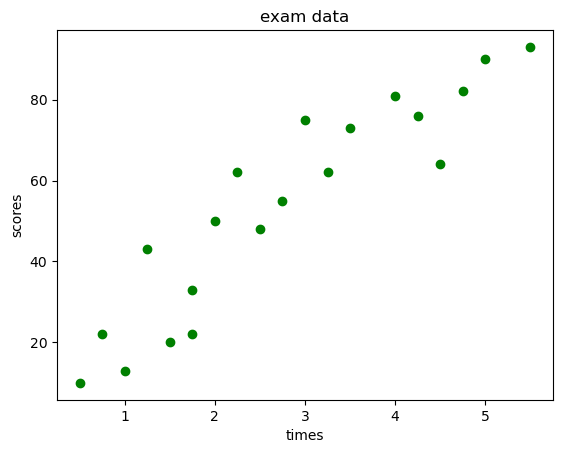

In [2]:
import matplotlib.pyplot as plt
exam_X = exam['学习时间']
exam_Y = exam['分数']
plt.scatter (exam_X, exam_Y, color = 'green')
plt.ylabel('scores')
plt.xlabel('times')
plt.title('exam data')
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(exam_X, exam_Y, train_size=0.8)

# 查看分割后的结果
print(X_train.head())
print(X_train.shape)

17    4.75
5     1.75
7     2.00
3     1.25
8     2.25
Name: 学习时间, dtype: float64
(16,)


.values将pandas DataFrame转换为numpy数组

reshape(-1, 1)是numpy数组的重塑操作，其中：

-1表示自动推断该维度的大小（根据总元素数量和其他维度大小计算），1表示指定该维度的大小为1

原始数据是pandas Series（一维），通过.values转换为numpy数组后，使用reshape(-1, 1)将其重塑为二维数组，形状为(n, 1)，即n行1列。

实际上，从你的输出来看，数据在reshape之前已经是二维的了。原始的pandas Series虽然在概念上是一维的，但通过.values获取的numpy数组在reshape之前是(16,)形状的一维数组。

reshape(-1, 1)操作将这个一维数组转换成了二维数组，形状变为(16, 1)，即16行1列。所以实际上是从一维变成了二维，而不是从二维变成一维。

数据形状的变化说明：

重塑前：pandas Series，概念上是一维的，形状为(16,)，显示为单列数据
重塑后：numpy二维数组，形状为(16, 1)，显示为16行1列的矩阵，用[[ ]]表示二维结构
这种转换通常是为了满足机器学习算法的输入要求，因为大多数sklearn算法期望输入是二维数组（样本数×特征数）。

Before Reshape:  
2     1.00
8     2.25
16    4.50
15    4.25
10    2.75
Name: 学习时间, dtype: float64
Before Reshape:  (16,)
After Reshape: 
[[1.  ]
 [2.25]
 [4.5 ]
 [4.25]
 [2.75]]
After Reshape:  (16, 1)

pandas确实是基于numpy构建的，但提供了额外的功能，如head()方法。pandas DataFrame和Series有head()方法，可以直接查看前几行数据，而numpy数组没有这个方法。

In [4]:
print("Before Reshape: ", X_train.head()) # 
print("Before Reshape: ", X_train.shape) # 
X_train = X_train.values.reshape(-1, 1) # 将X_train转换成2维数组, remove the 1st
X_test = X_test.values.reshape(-1, 1)   # 将X_test转换成2维数组

print("After Reshape: ", X_train[:5])   # numpy has no head() method 
print("After Reshape: ", X_train.shape) # shape is still available

#从skL中导入线性回归的模型

from sklearn.linear_model import LinearRegression
#创建模型
model = LinearRegression()
#训练模型
model.fit(X_train, Y_train)

Before Reshape:  17    4.75
5     1.75
7     2.00
3     1.25
8     2.25
Name: 学习时间, dtype: float64
Before Reshape:  (16,)
After Reshape:  [[4.75]
 [1.75]
 [2.  ]
 [1.25]
 [2.25]]
After Reshape:  (16, 1)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
print(model.predict([[1.5]]))  #预测学习4小时的考试成绩1.

[33.47371754]


In [ ]:
print(model.predict([[4.0]]))  #预测学习4小时的考试成绩

[71.39645345]


In [12]:
a = model.intercept_
b = model.coef_

print('该模型的截距为 : ', a)
print('该模型的斜率为 : ', b) # b is a numpy array for multiple features, so we need to access the first element

a = float(a)
b = float(b[0])  # b = float(b) deprecation warning after Numpy 1.25
print('该模型的线性回归方程为 : \n y= {} + {} *x   '.format(a, b))

该模型的截距为 :  10.720075997466743
该模型的斜率为 :  [15.16909436]
该模型的线性回归方程为 : 
 y= 10.720075997466743 + 15.169094363521218 *x   


Adj.R-squared
Adj.R-squared是R-squared的改进版,其目的是为了防止选取的特征变量过多而导致虚高的R-squared。每新增一个特征变量,线性回归背后的数学原理都会都会导致R-squared增加,但是这个新增的特征变量可能对模型并没有什么帮助。为了限制过多的特征变量,引入了Adj.R-squared的概念,它在R-squared的基础之上,额外考虑了特征变量的数量这一因素,其公式如下:

 R ^ 2 = 1 - ((1 - R ^ 2)(n - 1))/(n - k - 1)
 
其中R ^ 2为线性回归的R-squared,n为样本数量,k为特征变量数量。

从公式可以看出,k越大,会对Adj.R-squared产生负面影响,从而制约数据建模的人不要为了追求R-squared值而添加过多的特征变量。当考虑了特征变量数量后,Adj.R-squared就能够更准确的反映线性模型的拟合程度。

多元线性回归
多元线性回归的原理和一元线性回归的原理在本质上是一样的,不过因为多元线性回归可以考虑到多个因素对目标变量的影响,所以在实际应用中使用更为广泛。

y = b0 + b1*x1 + b2*x2 +... + bk*xk + e

使用LaTeX语法。  
$y = b_0 + b_1x_1 + b_2x_2 + \ldots + b_kx_k + e$

其中e为误差项,b0、b1、b2、bk为回归系数,x1、x2、x3......为特征变量,y为目标变量

Y = B + KX     # K, X 均为多维向量  
使用LaTeX语法。  
$y = A + Bx  + e$

其中x1、x2、x3......为不同的特征变量,k1,k2、k3......则为这些特征变量前的系数,ko为常数项。多元线性回归模型的搭建也是通过数学计算来获取合适的系数,使得如下所示的残差平方和最小,其中y(i) 为实际值, y^(i) 为预测值。

K
数学上依旧通过最小二乘法和梯度下降法来求解系数。具体步骤可参考最小二乘法知识点,这里主要讲解如何通过Python代码来求解系数。其核心代码和一元线性回归其实是一致的,具体如下:


In [ ]:

# from sklearn.linear_model import LinearRegression
# regr = LinearRegression()
# regr.fit(X, Y)